In [2]:
import pandas as pd
data = pd.read_csv('wine+quality/winequality-red.csv')
df = pd.DataFrame(data)
print("shape: ", df.shape)
df.info()
df.head()

shape:  (1599, 12)
<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
df.isna()
df.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [4]:
df.duplicated()[df.duplicated()==True]

4       True
11      True
27      True
40      True
65      True
        ... 
1563    True
1564    True
1567    True
1581    True
1596    True
Length: 240, dtype: bool

In [5]:
df.drop_duplicates()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
5,7.4,0.660,0.00,1.8,0.075,13.0,40.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1593,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [6]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


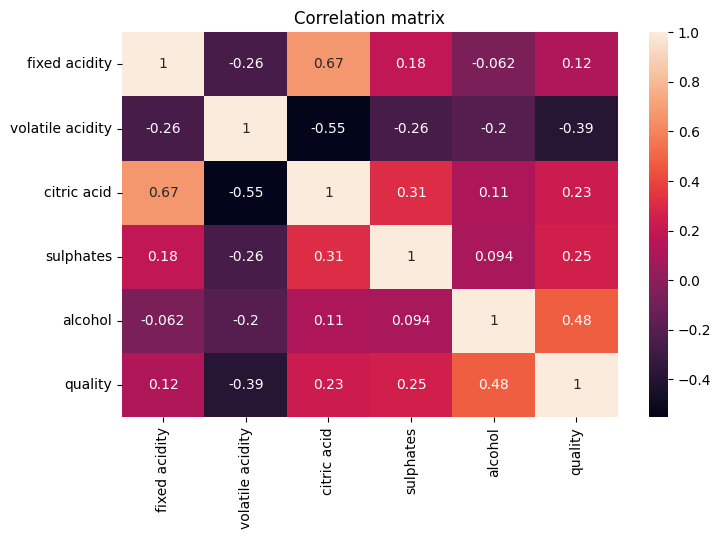

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.heatmap(df[['fixed acidity', 'volatile acidity', 'citric acid', 'sulphates', 'alcohol', 'quality']].corr(), annot=True)
plt.title("Correlation matrix")
plt.show()

We can see here that acidity tends to play a pretty strong role in the quality of the wine. So does alcohol.

<Axes: xlabel='quality'>

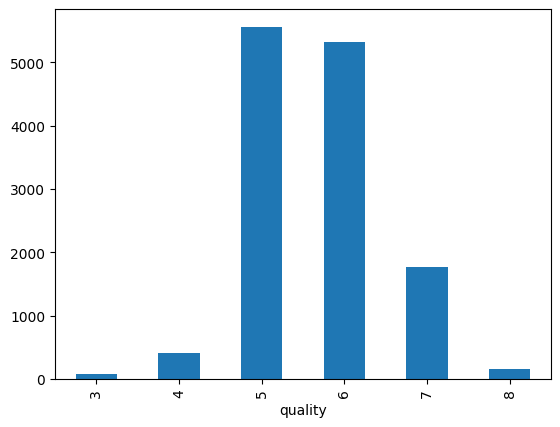

In [8]:
quality_vs_fixed_acidity = df.groupby("quality")['fixed acidity'].sum()
quality_vs_fixed_acidity.plot(kind='bar')

The bar graph shows that the quality of the wine tends to be mediocre the more fixed acidity is introduced.

<Axes: xlabel='quality'>

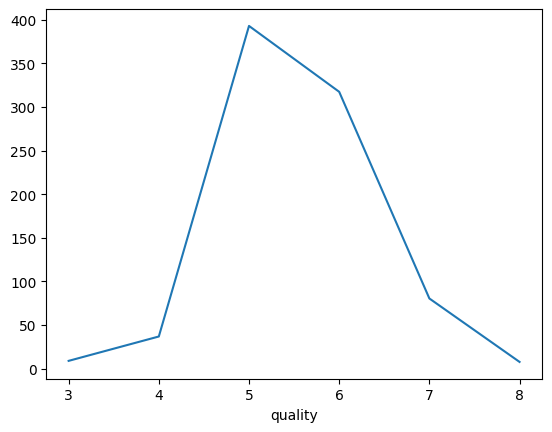

In [9]:
quality_vs_volatile_acidify = df.groupby('quality')['volatile acidity'].sum()
quality_vs_volatile_acidify.plot()

<Axes: xlabel='quality'>

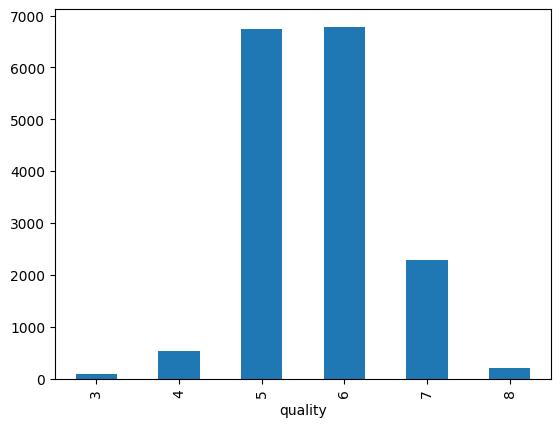

In [10]:
alcohol_vs_quality = df.groupby('quality')['alcohol'].sum()
alcohol_vs_quality.plot(kind='bar')

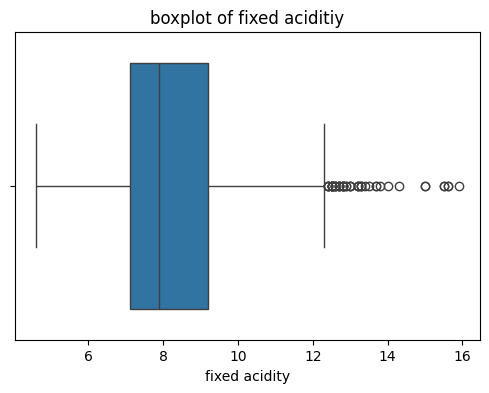

In [11]:
plt.figure(figsize=[6, 4])
sns.boxplot(x=df['fixed acidity'])
plt.title("boxplot of fixed aciditiy")
plt.show()

Far too many outliers. Removing them feels like it might incapacitate our dataset.

In [12]:
lower_cap = df['fixed acidity'].quantile(0.05)
upper_cap = df['fixed acidity'].quantile(0.95)

df_capped = df.copy()
df_capped['fixed acidity'] = df_capped['fixed acidity'].clip(lower_cap, upper_cap)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_standardized = df[['alcohol', 'quality']].copy()
df_standardized[['alcohol', 'quality']] = scaler.fit_transform(df_standardized)

df_standardized.head()

,alcohol,quality
0,-0.960246,-0.787823
1,-0.584777,-0.787823
2,-0.584777,-0.787823
3,-0.584777,0.450848
4,-0.960246,-0.787823


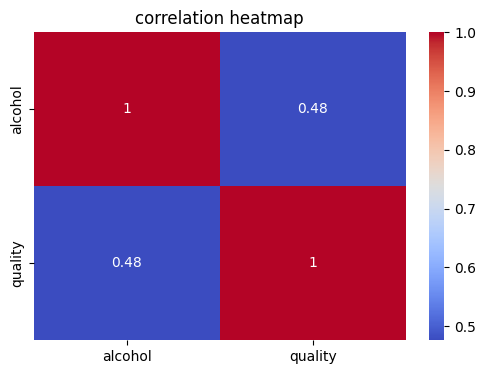

In [14]:
plt.figure(figsize=(6,4))
sns.heatmap(df_standardized[['alcohol', 'quality']].corr(), annot=True, cmap="coolwarm")
plt.title("correlation heatmap")
plt.show()

In [15]:
from sklearn.decomposition import PCA

X = df_standardized[['alcohol', 'quality']]

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.73808316 0.26191684]


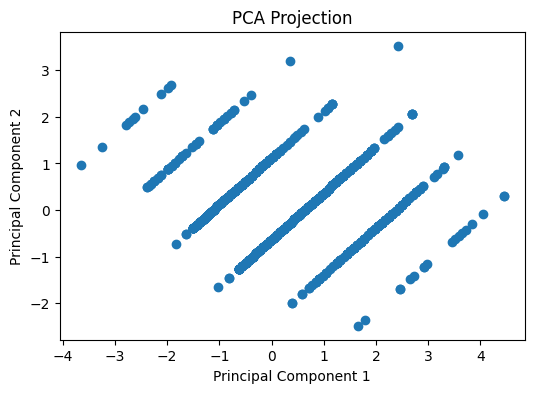

In [16]:
plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1])
plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [18]:
target_col = "quality"
df[target_col].value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

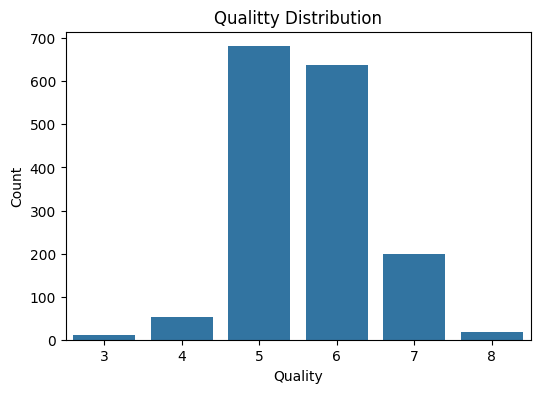

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(x=target_col, data=df)
plt.title("Qualitty Distribution")
plt.xlabel("Quality")
plt.ylabel("Count")
plt.show()

In [20]:
df.dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

In [21]:
df['alcohol_content_per_quality'] = df['alcohol']/df['quality']
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,alcohol_content_per_quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1.880000
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1.960000
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,1.960000
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1.633333
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1.880000
